In [1]:
import os
import cv2
import glob
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from tqdm import tqdm

from sklearn.model_selection import train_test_split

import tensorflow as tf
from tensorflow.keras import layers, Model

from skimage.metrics import peak_signal_noise_ratio
from skimage.metrics import structural_similarity

2026-06-05 15:09:15.092605: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1780672155.277581      58 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1780672155.337576      58 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1780672155.799818      58 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1780672155.799861      58 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1780672155.799864      58 computation_placer.cc:177] computation placer alr

In [2]:
UIEB_RAW = "/kaggle/input/datasets/larjeck/uieb-dataset-raw/raw-890"

UIEB_REF = "/kaggle/input/datasets/larjeck/uieb-dataset-reference/reference-890"

SEATHRU = "/kaggle/input/datasets/colorlabeilat/seathru-dataset"

In [3]:
raw_paths = sorted(
    glob.glob(UIEB_RAW + "/*.png")
)

ref_paths = sorted(
    glob.glob(UIEB_REF + "/*.png")
)

seathru_imgs = glob.glob(
    SEATHRU + "/**/linearPNG/*.png",
    recursive=True
)

print("UIEB Raw :", len(raw_paths))
print("UIEB Ref :", len(ref_paths))
print("SeaThru  :", len(seathru_imgs))

UIEB Raw : 890
UIEB Ref : 890
SeaThru  : 1216


In [4]:
pairs = []

for raw_path in raw_paths:

    filename = os.path.basename(raw_path)

    ref_path = os.path.join(
        UIEB_REF,
        filename
    )

    if os.path.exists(ref_path):
        pairs.append(
            (raw_path, ref_path)
        )

print("Total Pair:", len(pairs))

Total Pair: 890


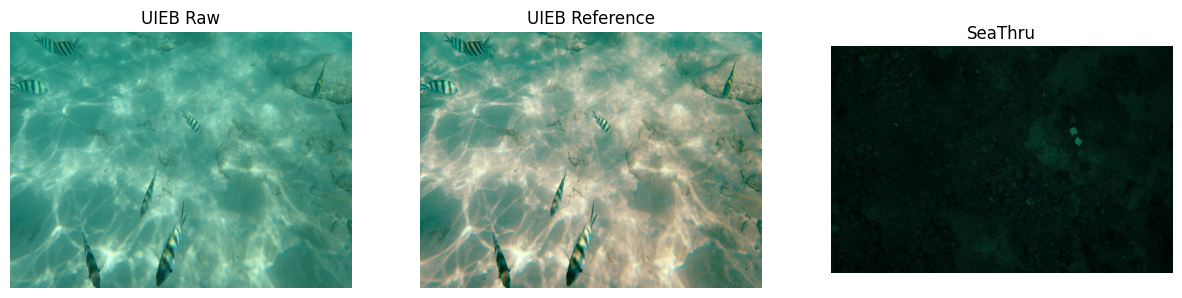

In [5]:
sample = 100

raw = cv2.imread(pairs[sample][0])
raw = cv2.cvtColor(raw, cv2.COLOR_BGR2RGB)

ref = cv2.imread(pairs[sample][1])
ref = cv2.cvtColor(ref, cv2.COLOR_BGR2RGB)

sea = cv2.imread(seathru_imgs[sample])
sea = cv2.cvtColor(sea, cv2.COLOR_BGR2RGB)

plt.figure(figsize=(15,5))

plt.subplot(1,3,1)
plt.imshow(raw)
plt.title("UIEB Raw")
plt.axis("off")

plt.subplot(1,3,2)
plt.imshow(ref)
plt.title("UIEB Reference")
plt.axis("off")

plt.subplot(1,3,3)
plt.imshow(sea)
plt.title("SeaThru")
plt.axis("off")

plt.show()

In [6]:
sizes = []

for p,_ in pairs:

    img = cv2.imread(p)

    h,w,_ = img.shape

    sizes.append([h,w])

sizes = pd.DataFrame(
    sizes,
    columns=["Height","Width"]
)

sizes.describe()

,Height,Width
count,890.000000,890.000000
mean,594.791011,868.903371
std,287.705001,417.880815
min,159.000000,225.000000
25%,375.000000,580.000000
50%,480.000000,664.000000
75%,720.000000,1280.000000
max,1450.000000,2180.000000


In [7]:
IMG_SIZE = 256

def preprocess(path):

    img = cv2.imread(path)

    img = cv2.cvtColor(
        img,
        cv2.COLOR_BGR2RGB
    )

    img = cv2.resize(
        img,
        (IMG_SIZE, IMG_SIZE)
    )

    img = img.astype(np.float32)/255.0

    return img

In [8]:
X = []
Y = []

for raw_path, ref_path in tqdm(pairs):

    X.append(
        preprocess(raw_path)
    )

    Y.append(
        preprocess(ref_path)
    )

X = np.array(X)
Y = np.array(Y)

print(X.shape)
print(Y.shape)

100%|██████████| 890/890 [00:43<00:00, 20.51it/s]


(890, 256, 256, 3)
(890, 256, 256, 3)


In [9]:
X_train, X_temp, Y_train, Y_temp = train_test_split(
    X,
    Y,
    test_size=0.30,
    random_state=42
)

X_val, X_test, Y_val, Y_test = train_test_split(
    X_temp,
    Y_temp,
    test_size=0.50,
    random_state=42
)

In [10]:
print(X_train.shape)
print(X_val.shape)
print(X_test.shape)

(623, 256, 256, 3)
(133, 256, 256, 3)
(134, 256, 256, 3)


In [11]:
BATCH_SIZE = 8

train_ds = tf.data.Dataset.from_tensor_slices(
    (X_train,Y_train)
)

train_ds = train_ds.shuffle(
    1000
).batch(BATCH_SIZE)

val_ds = tf.data.Dataset.from_tensor_slices(
    (X_val,Y_val)
).batch(BATCH_SIZE)

I0000 00:00:1780672242.115722      58 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 15511 MB memory:  -> device: 0, name: Tesla P100-PCIE-16GB, pci bus id: 0000:00:04.0, compute capability: 6.0


In [12]:
def down_block(x, filters, bn=True):

    x = layers.Conv2D(
        filters,
        4,
        strides=2,
        padding='same'
    )(x)

    if bn:
        x = layers.BatchNormalization()(x)

    x = layers.LeakyReLU(0.2)(x)

    return x

In [13]:
def up_block(x, skip, filters):

    x = layers.Conv2DTranspose(
        filters,
        4,
        strides=2,
        padding='same'
    )(x)

    x = layers.BatchNormalization()(x)

    x = layers.ReLU()(x)

    x = layers.Concatenate()(
        [x,skip]
    )

    return x

In [14]:
def build_generator():

    inputs = layers.Input(
        shape=(256,256,3)
    )

    d1 = down_block(
        inputs,
        64,
        bn=False
    )

    d2 = down_block(d1,128)
    d3 = down_block(d2,256)
    d4 = down_block(d3,512)
    d5 = down_block(d4,512)

    u1 = up_block(d5,d4,512)
    u2 = up_block(u1,d3,256)
    u3 = up_block(u2,d2,128)
    u4 = up_block(u3,d1,64)

    outputs = layers.Conv2DTranspose(
        3,
        4,
        strides=2,
        padding='same',
        activation='sigmoid'
    )(u4)

    return Model(
        inputs,
        outputs
    )

In [15]:
generator = build_generator()

In [16]:
def build_discriminator():

    inp = layers.Input(
        shape=(256,256,3)
    )

    tar = layers.Input(
        shape=(256,256,3)
    )

    x = layers.Concatenate()(
        [inp,tar]
    )

    x = down_block(
        x,
        64,
        bn=False
    )

    x = down_block(x,128)
    x = down_block(x,256)
    x = down_block(x,512)

    outputs = layers.Conv2D(
        1,
        4,
        padding='same'
    )(x)

    return Model(
        [inp,tar],
        outputs
    )

In [17]:
discriminator = build_discriminator()

In [18]:
from tensorflow.keras.applications import VGG19

vgg = VGG19(
    include_top=False,
    weights='imagenet',
    input_shape=(256,256,3)
)

vgg.trainable = False

80134624/80134624 ━━━━━━━━━━━━━━━━━━━━ 4s 0us/step


In [19]:
content_model = tf.keras.Model(
    inputs=vgg.input,
    outputs=vgg.get_layer(
        'block5_conv2'
    ).output
)

In [20]:
loss_fn = tf.keras.losses.BinaryCrossentropy(
    from_logits=True
)

LAMBDA_L1 = 100
LAMBDA_CONTENT = 10

In [21]:
def perceptual_loss(
    target,
    generated
):

    target_feat = content_model(
        target
    )

    generated_feat = content_model(
        generated
    )

    return tf.reduce_mean(
        tf.square(
            target_feat-generated_feat
        )
    )

In [22]:
def generator_loss(
    fake_output,
    generated,
    target
):

    gan_loss = loss_fn(
        tf.ones_like(fake_output),
        fake_output
    )

    l1_loss = tf.reduce_mean(
        tf.abs(
            target-generated
        )
    )

    content_loss = perceptual_loss(
        target,
        generated
    )

    total = (
        gan_loss +
        LAMBDA_L1*l1_loss +
        LAMBDA_CONTENT*content_loss
    )

    return total

In [23]:
def discriminator_loss(
    real_output,
    fake_output
):

    real_loss = loss_fn(
        tf.ones_like(real_output),
        real_output
    )

    fake_loss = loss_fn(
        tf.zeros_like(fake_output),
        fake_output
    )

    return real_loss + fake_loss

In [24]:
gen_opt = tf.keras.optimizers.Adam(
    2e-4,
    beta_1=0.5
)

disc_opt = tf.keras.optimizers.Adam(
    2e-4,
    beta_1=0.5
)

In [25]:
@tf.function
def train_step(
    inp,
    target
):

    with tf.GradientTape() as gen_tape,\
         tf.GradientTape() as disc_tape:

        generated = generator(
            inp,
            training=True
        )

        real_output = discriminator(
            [inp,target],
            training=True
        )

        fake_output = discriminator(
            [inp,generated],
            training=True
        )

        gen_loss = generator_loss(
            fake_output,
            generated,
            target
        )

        disc_loss = discriminator_loss(
            real_output,
            fake_output
        )

    gen_gradients = gen_tape.gradient(
        gen_loss,
        generator.trainable_variables
    )

    disc_gradients = disc_tape.gradient(
        disc_loss,
        discriminator.trainable_variables
    )

    gen_opt.apply_gradients(
        zip(
            gen_gradients,
            generator.trainable_variables
        )
    )

    disc_opt.apply_gradients(
        zip(
            disc_gradients,
            discriminator.trainable_variables
        )
    )

    return gen_loss, disc_loss

In [26]:
best_val_loss = np.inf

train_history = []
val_history = []

EPOCHS = 100

for epoch in range(EPOCHS):

    train_losses = []

    for inp,target in train_ds:

        gl,dl = train_step(
            inp,
            target
        )

        train_losses.append(
            gl.numpy()
        )

    val_losses = []

    for inp,target in val_ds:

        generated = generator(
            inp,
            training=False
        )

        fake_output = discriminator(
            [inp,generated],
            training=False
        )

        vloss = generator_loss(
            fake_output,
            generated,
            target
        )

        val_losses.append(
            vloss.numpy()
        )

    train_mean = np.mean(
        train_losses
    )

    val_mean = np.mean(
        val_losses
    )

    train_history.append(
        train_mean
    )

    val_history.append(
        val_mean
    )

    print(
        f"Epoch {epoch+1}/{EPOCHS}"
        f" | Train={train_mean:.4f}"
        f" | Val={val_mean:.4f}"
    )

    if val_mean < best_val_loss:

        best_val_loss = val_mean

        generator.save(
            "/kaggle/working/best_generator.keras"
        )

        print(
            "Best Model Saved"
        )

I0000 00:00:1780672260.506983     137 cuda_dnn.cc:529] Loaded cuDNN version 91002


Epoch 1/100 | Train=18.2576 | Val=26.4418
Best Model Saved
Epoch 2/100 | Train=14.1000 | Val=22.5215
Best Model Saved
Epoch 3/100 | Train=13.5032 | Val=20.7868
Best Model Saved
Epoch 4/100 | Train=12.9683 | Val=18.9225
Best Model Saved
Epoch 5/100 | Train=12.5560 | Val=17.6054
Best Model Saved
Epoch 6/100 | Train=12.2823 | Val=14.6830
Best Model Saved
Epoch 7/100 | Train=12.1939 | Val=13.1390
Best Model Saved
Epoch 8/100 | Train=11.7820 | Val=12.4104
Best Model Saved
Epoch 9/100 | Train=11.6120 | Val=12.0834
Best Model Saved
Epoch 10/100 | Train=11.4900 | Val=11.3433
Best Model Saved
Epoch 11/100 | Train=11.0595 | Val=11.4952
Epoch 12/100 | Train=10.9274 | Val=11.9647
Epoch 13/100 | Train=10.7261 | Val=13.2038
Epoch 14/100 | Train=10.5182 | Val=10.9565
Best Model Saved
Epoch 15/100 | Train=10.3540 | Val=11.2541
Epoch 16/100 | Train=10.0351 | Val=10.2773
Best Model Saved
Epoch 17/100 | Train=9.7960 | Val=11.7174
Epoch 18/100 | Train=9.4262 | Val=11.1680
Epoch 19/100 | Train=9.2176 | Val

In [27]:
generator = tf.keras.models.load_model(
    "/kaggle/working/best_generator.keras",
    compile=False
)

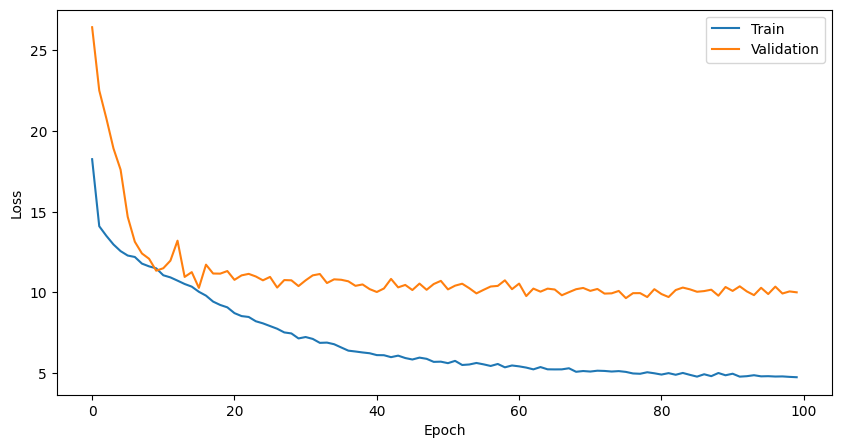

In [28]:
plt.figure(figsize=(10,5))

plt.plot(
    train_history,
    label="Train"
)

plt.plot(
    val_history,
    label="Validation"
)

plt.xlabel("Epoch")
plt.ylabel("Loss")

plt.legend()

plt.show()

In [29]:
pred = generator.predict(X_test)

I0000 00:00:1780674166.500662     135 service.cc:152] XLA service 0x7a08b4663630 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1780674166.500739     135 service.cc:160]   StreamExecutor device (0): Tesla P100-PCIE-16GB, Compute Capability 6.0


2/5 ━━━━━━━━━━━━━━━━━━━━ 0s 105ms/step

I0000 00:00:1780674168.914346     135 device_compiler.h:188] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


5/5 ━━━━━━━━━━━━━━━━━━━━ 4s 408ms/step


In [36]:
import cv2
import numpy as np

# =====================================
# UCIQE
# =====================================

def uciqe(img):

    img = (img * 255).astype(np.uint8)

    lab = cv2.cvtColor(
        img,
        cv2.COLOR_RGB2LAB
    )

    L = lab[:,:,0].astype(np.float32)
    a = lab[:,:,1].astype(np.float32)
    b = lab[:,:,2].astype(np.float32)

    chroma = np.sqrt(a**2 + b**2)

    sigma_c = np.std(chroma)

    con_l = np.percentile(L, 99) - np.percentile(L, 1)

    saturation = chroma / np.sqrt(
        chroma**2 + L**2 + 1e-8
    )

    mu_s = np.mean(saturation)

    return (
        0.4680 * sigma_c +
        0.2745 * con_l +
        0.2576 * mu_s
    )

# =====================================
# UICM
# =====================================

def _uicm(img):

    R = img[:,:,0]
    G = img[:,:,1]
    B = img[:,:,2]

    rg = R - G
    yb = (R + G)/2 - B

    mu_rg = np.mean(rg)
    mu_yb = np.mean(yb)

    sigma_rg = np.std(rg)
    sigma_yb = np.std(yb)

    return (
        -0.0268 *
        np.sqrt(mu_rg**2 + mu_yb**2)
        +
        0.1586 *
        np.sqrt(sigma_rg**2 + sigma_yb**2)
    )

# =====================================
# UISM
# =====================================

def _uism(img):

    img255 = (img * 255).astype(np.uint8)

    r = img255[:,:,0]
    g = img255[:,:,1]
    b = img255[:,:,2]

    sobel_r = cv2.Sobel(r, cv2.CV_64F, 1, 1)
    sobel_g = cv2.Sobel(g, cv2.CV_64F, 1, 1)
    sobel_b = cv2.Sobel(b, cv2.CV_64F, 1, 1)

    eme_r = np.mean(np.abs(sobel_r))
    eme_g = np.mean(np.abs(sobel_g))
    eme_b = np.mean(np.abs(sobel_b))

    return (
        0.299 * eme_r +
        0.587 * eme_g +
        0.114 * eme_b
    )

# =====================================
# UIConM
# =====================================

def _uiconm(img):

    gray = cv2.cvtColor(
        (img * 255).astype(np.uint8),
        cv2.COLOR_RGB2GRAY
    ).astype(np.float32)

    max_val = np.max(gray)
    min_val = np.min(gray)

    return (
        (max_val - min_val)
        /
        (max_val + min_val + 1e-8)
    )

# =====================================
# UIQM
# =====================================

def uiqm(img):

    uicm = _uicm(img)
    uism = _uism(img)
    uiconm = _uiconm(img)

    return (
        0.0282 * uicm +
        0.2953 * uism +
        3.5753 * uiconm
    )

In [37]:
from skimage.metrics import peak_signal_noise_ratio
from skimage.metrics import structural_similarity

psnr_scores = []
ssim_scores = []

for i in range(len(X_test)):

    psnr_scores.append(
        peak_signal_noise_ratio(
            Y_test[i],
            pred[i],
            data_range=1.0
        )
    )

    ssim_scores.append(
        structural_similarity(
            Y_test[i],
            pred[i],
            channel_axis=2,
            data_range=1.0
        )
    )

In [38]:
sea_images = np.array([
    preprocess(path)
    for path in seathru_imgs
])

enhanced_sea = generator.predict(
    sea_images,
    batch_size=8,
    verbose=0
)

uciqe_scores = [
    uciqe(img)
    for img in enhanced_sea
]

uiqm_scores = [
    uiqm(img)
    for img in enhanced_sea
]

In [39]:
import pandas as pd

results = pd.DataFrame({
    "Metric": [
        "PSNR",
        "SSIM",
        "UCIQE",
        "UIQM"
    ],
    "Value": [
        np.mean(psnr_scores),
        np.mean(ssim_scores),
        np.mean(uciqe_scores),
        np.mean(uiqm_scores)
    ]
})

print(results)

  Metric      Value
0   PSNR  19.638463
1   SSIM   0.831074
2  UCIQE  35.254303
3   UIQM   6.925908


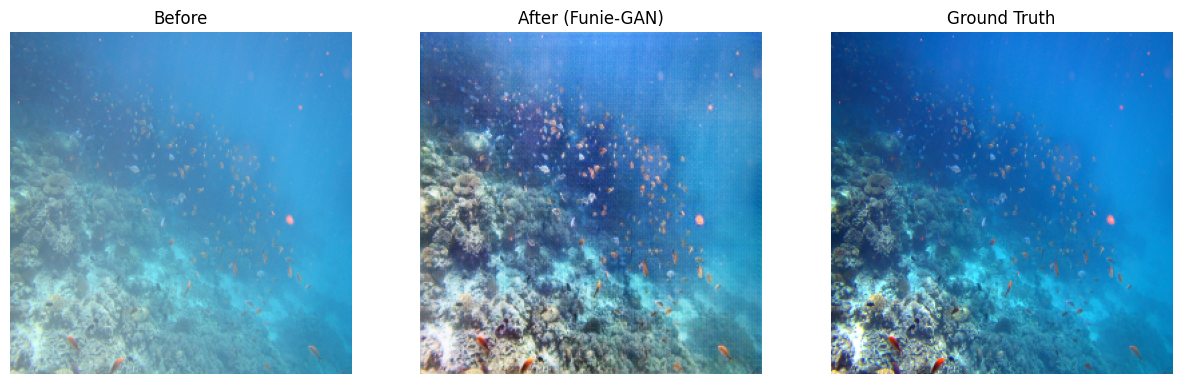

In [40]:
# Pilih contoh terbaik
idx = 10

fig, ax = plt.subplots(1,3, figsize=(15,5))

ax[0].imshow(X_test[idx])
ax[0].set_title("Before")

ax[1].imshow(pred[idx])
ax[1].set_title("After (Funie-GAN)")

ax[2].imshow(Y_test[idx])
ax[2].set_title("Ground Truth")

for a in ax:
    a.axis("off")

plt.show()

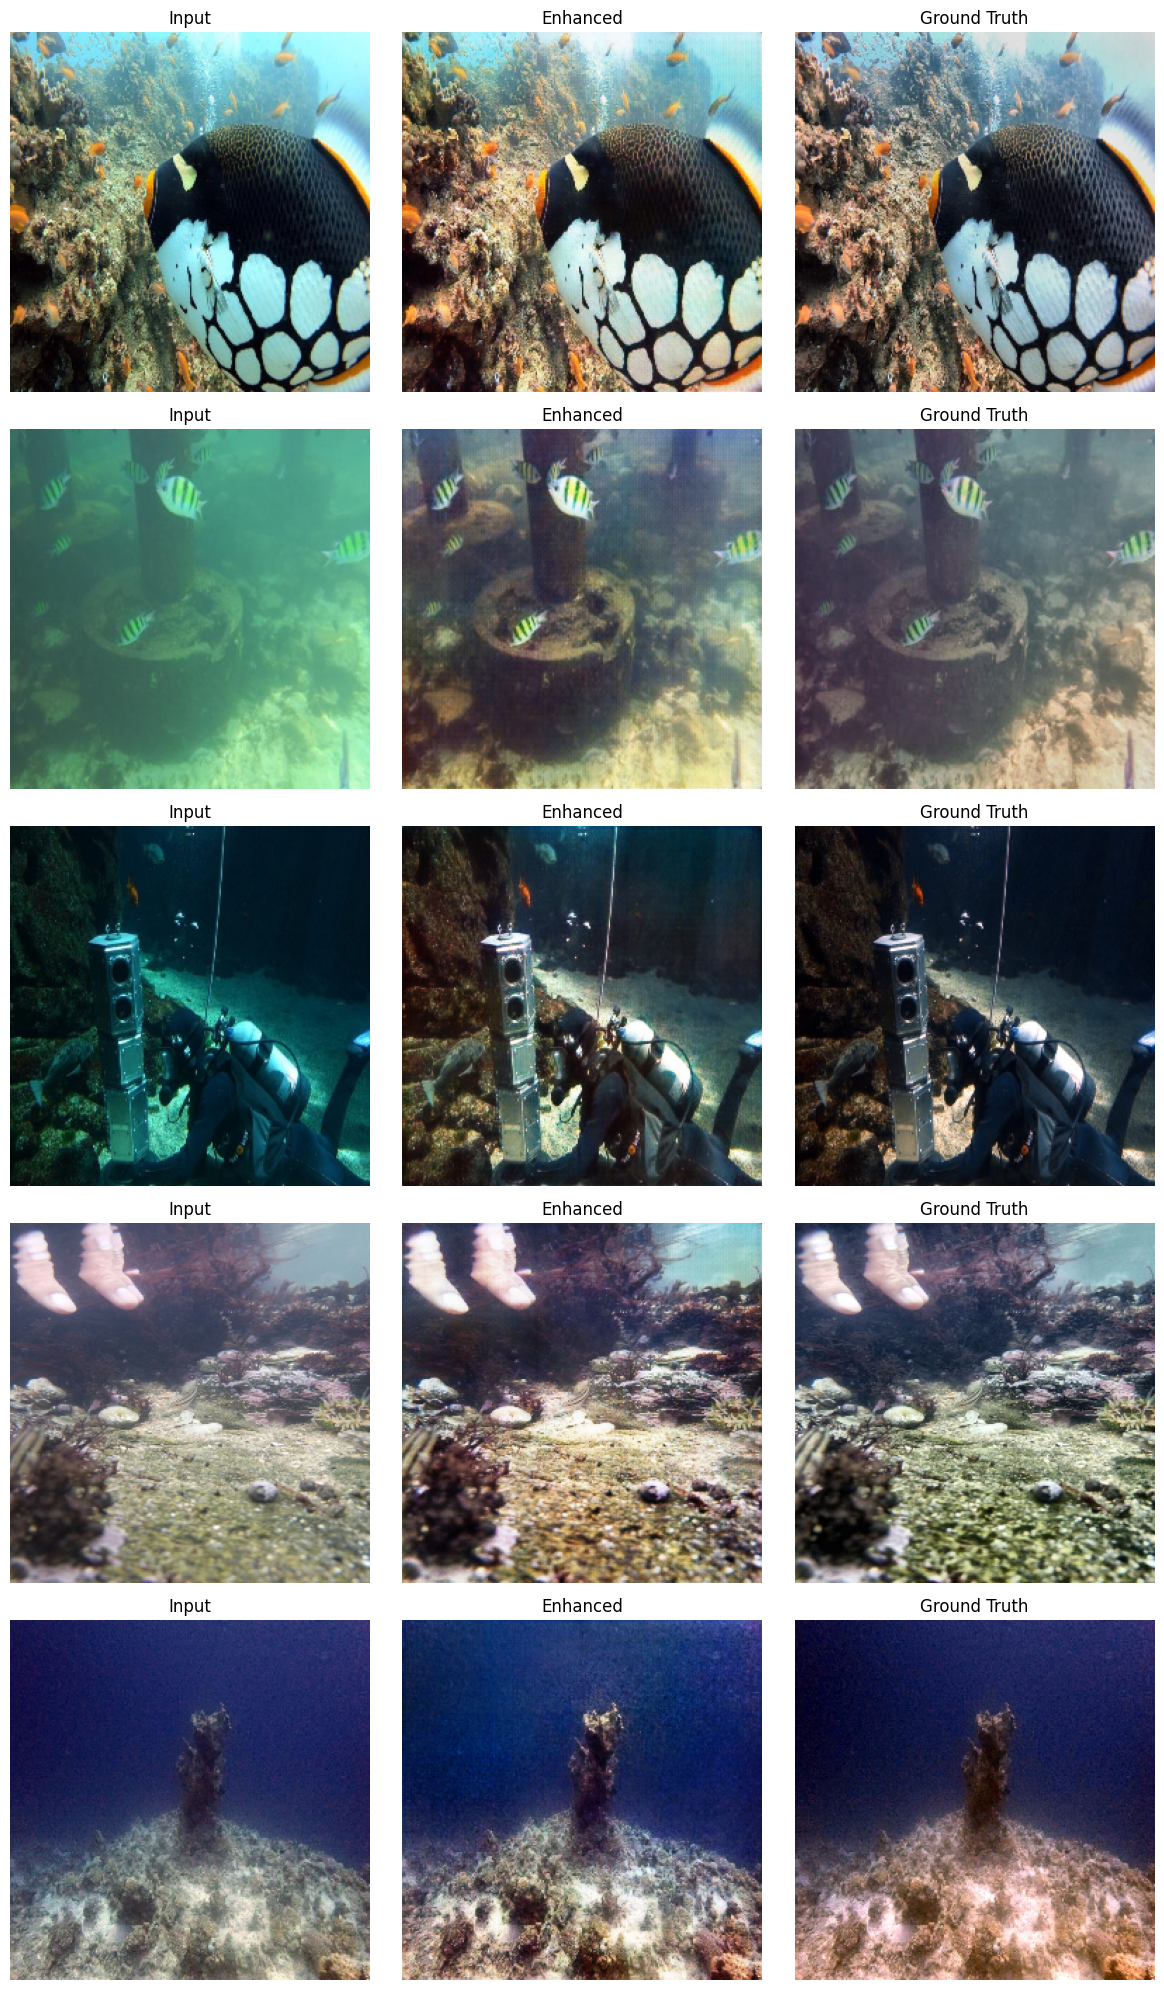

In [41]:
import matplotlib.pyplot as plt
import numpy as np

n_samples = 5

indices = np.random.choice(
    len(X_test),
    n_samples,
    replace=False
)

fig, axes = plt.subplots(
    n_samples,
    3,
    figsize=(12, 4*n_samples)
)

for row, idx in enumerate(indices):

    axes[row,0].imshow(X_test[idx])
    axes[row,0].set_title("Input")

    axes[row,1].imshow(pred[idx])
    axes[row,1].set_title("Enhanced")

    axes[row,2].imshow(Y_test[idx])
    axes[row,2].set_title("Ground Truth")

    for col in range(3):
        axes[row,col].axis("off")

plt.tight_layout()
plt.show()